In [16]:
# Librerias usadas para la implementación del trabajo:

import numpy as np
import matplotlib.pyplot as plt

from math import comb # Para utilizar en el ejercicio de la podadora robot.

[[1, 0, 0, 0], [0, 0, 0, 1]]


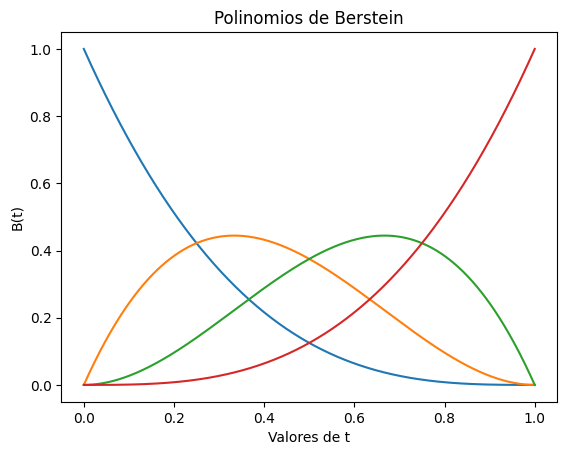

True


In [17]:
# Ejercicio 1
# Funciones base de Berstein de grado 3 
# Las bases de berstein son las que multiplicadas por los puntos de control representan una curva de bezier cubica. 
# Estas siempre sumaran uno en una en los t pertenecientes a [0,1]. Dependiendo el t vemos como cambia cada una de sus formas. 

# a) Implementar una funcion berstein3(t) que dado un arreglo t devuelva una matriz con las cuatro funciones evaluadas en esos valores
# Para cada t una posicion en la matriz?

def berstein3(t:list):
    # t debe pertenecer a [0,1]
     
    res = []
    for i in t:
        b1 = (1-i)**3
        b2 = 3*((1-i)**2)*i
        b3 = (3*(1-i))*i**2
        b4 = i**3

        lista_t = [b1,b2,b3,b4]
        res.append(lista_t)

    return res

print(berstein3([0,1]))

# b) Graficar las cuatro funciones en el intervalo [0,1]
# Con numpy podemos graficar
        
x_values = np.linspace(0,1,500)
y_value1 = (1-x_values)**3
y_value2 = 3*((1-x_values)**2)*x_values
y_value3 = (3*(1-x_values))*x_values**2
y_value4 = x_values**3

plt.plot(x_values, y_value1)
plt.plot(x_values, y_value2)
plt.plot(x_values, y_value3)
plt.plot(x_values, y_value4)

plt.title("Polinomios de Berstein")
plt.xlabel("Valores de t")
plt.ylabel("B(t)")

plt.show()

# c) Verificar que para todo t en [0,1] se cumple que la suma de los polinomios de Berstein da 1.
# Tengo que sumar cada fila de berstein(t) y si me da 1 significa que todos los t´s dan 1.

def evaluar_polinomios_berstein():
    evaluar = berstein3([0,1])
    res = True
    for i in evaluar:
        if sum(i) != 1:
            res = False
            return res
        
    return res

print(evaluar_polinomios_berstein())

# d) 
# Como la respuesta es True, vemos que para todo t dentro de [0,1] la suma de los polinomios de Berstein es 1.
# Esto nos da a entender que los polinomios indican cuanto peso esta teniendo cada punto de control para cada valor de t.
# Una curva de Bezier es una combinación de puntos de control ya que para cada polinomio asociado a un punto de control el t indica cuanto se "enciende" ese punto de control.

# Si el valor total de la suma de polinomios de Berstein no es 1, entonces, no tocaria los puntos extremos y no se mantendria entre las rectas que tienen los puntos de control.
# Tambien, que el valor sea 1 significa que cuando transladas los puntos de control, la curva se translada respetando la forma incial.


[[np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)], [np.float64(0.9700020303019998), np.float64(0.029693939703122445), np.float64(0.0003029993847257392), np.float64(1.0306101521283648e-06)], [np.float64(0.9406100593734508), np.float64(0.058182065528254695), np.float64(0.0011996302170774165), np.float64(8.244881217026918e-06)], [np.float64(0.9118179035534408), np.float64(0.08548292845813507), np.float64(0.0026713415143167214), np.float64(2.7826474107465846e-05)], [np.float64(0.8836193791810565), np.float64(0.11161507947550188), np.float64(0.004699582293705343), np.float64(6.595904973621535e-05)], [np.float64(0.8560083025953855), np.float64(0.13659706956309345), np.float64(0.007265801572504973), np.float64(0.00012882626901604562)], [np.float64(0.8289784901355151), np.float64(0.16044744970364805), np.float64(0.010351448367977295), np.float64(0.00022261179285972677)], [np.float64(0.8025237581405319), np.float64(0.18318477087990406), np.float64(0.013937971697384009), np.f

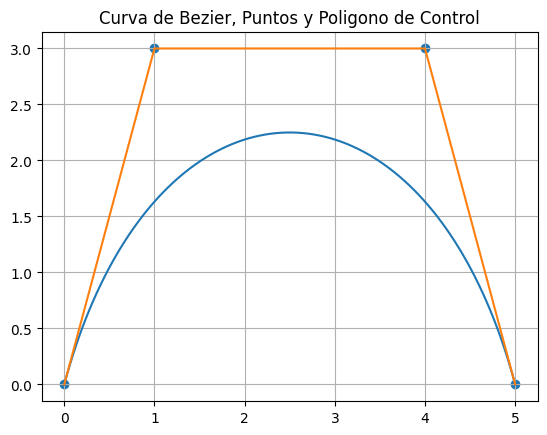

In [18]:
# Ejercicio 2 - Evaluacion Matricial de una curva de Bezier

# p0 = (0,0); p1 = (1,3); p2 = (4,3); p3 = (5,0)

# a) Construir una matriz de R^100*4 con 100 valores equiespaciados entre t perteneciente [0,1]

p0 = [0.0,0.0]
p1 = [1.0,3.0]
p2 = [4.0,3.0]
p3 = [5.0,0.0] 

def matriz100x4(): 

    res = []
    contador = 0
    i = 0.0
    for i in np.linspace(0, 1, 100): 
        
        if contador == 100:
            return res
        contador = contador + 1

        b1 = (1-i)**3
        b2 = 3*((1-i)**2)*i
        b3 = (3*(1-i))*i**2
        b4 = i**3
        
        res.append([b1,b2,b3,b4])

        i = i + 0.01
        

    return res

print(matriz100x4())
# Me da una matriz de 100 filas. En cada fila se suma 0.01 a cada numero, yendo de t [0,1]. Viendo 100 numeros distintos con diferencia de 0.01.

# b) Construir una matriz 4x2 que tenga los puntos de control.

def matriz_puntos_control(p0,p1,p2,p3):
    res = []
    res.append(p0)
    res.append(p1)
    res.append(p2)
    res.append(p3)
    return res

print(matriz_puntos_control(p0,p1,p2,p3))

# c) Calcular los productos de la curva mediante a C = A*P

A = matriz100x4()
P = matriz_puntos_control(p0,p1,p2,p3)
A = np.array(matriz100x4())
P = np.array(matriz_puntos_control(p0,p1,p2,p3))
C = A @ P
print(C)

# d) Graficar la curva, los puntos de control y el poligono de control.

def puntos_x(C): # Calcula puntos x para dsp plotearlos
    res = []
    bezier = C
    for i in range(len(bezier)):
        res.append([bezier[i][0]])
    return res

def puntos_y(C): # Calcula puntos x para dsp plotearlos
    res = []
    bezier = C
    for i in range(len(bezier)):
        res.append([bezier[i][1]])
    return res

x_valores = puntos_x(C)
y_valores = puntos_y(C)

plt.plot(x_valores, y_valores) #grafica la curva de bezier

puntox = [0,1,4,5]
puntoy = [0,3,3,0]
plt.scatter(puntox, puntoy) # scatter grafica los puntos
plt.plot(puntox, puntoy) # grafica el poligono de control

plt.title("Curva de Bezier, Puntos y Poligono de Control")

plt.grid()
plt.show()


# e) Indicar las dimensiones de A, P y C.  Explicar que representa cada matriz

# La matriz A contiene los 100 valores de los 4 polinomios de berstein, tiene dimensiones 100 filas x 4 columnas.
# La matriz P contiene los 4 puntos de control, tiene dimensiones 2 filas x 4 columnas

# La matriz C contiene la curva de bezier cubica. Para obtenerla cada punto de control se multiplico a su valor de berstein correspondiente y se sumo los resultados divididos en x e y.
# Ej: el punto de control p0 se multiplica por la curva de berstein 1, asi sumando cada valor para el eje x e y.
# C tiene dimension 100 x 2.


[0, 0.03, 0.06, 0.09, 0.12, 0.15, 0.18, 0.21, 0.24, 0.27, 0.30000000000000004, 0.33000000000000007, 0.3600000000000001, 0.3900000000000001, 0.42000000000000015, 0.4500000000000002, 0.4800000000000002, 0.5100000000000002, 0.5400000000000003, 0.5700000000000003, 0.6000000000000003, 0.6300000000000003, 0.6600000000000004, 0.6900000000000004, 0.7200000000000004, 0.7500000000000004, 0.7800000000000005, 0.8100000000000005, 0.8400000000000005, 0.8700000000000006]
[[0, 0], [0.09529199999999999, 0.26189999999999997], [0.200736, 0.5076], [0.315684, 0.7371000000000001], [0.439488, 0.9504], [0.5714999999999999, 1.1475], [0.711072, 1.3284], [0.857556, 1.4931], [1.010304, 1.6416], [1.168668, 1.7738999999999998], [1.332, 1.8900000000000001], [1.4996520000000004, 1.9899], [1.6709760000000005, 2.0736], [1.8453240000000006, 2.1411000000000002], [2.0220480000000007, 2.1924], [2.200500000000001, 2.2275], [2.3800320000000013, 2.2464], [2.5599960000000013, 2.2491000000000003], [2.7397440000000017, 2.2356], 

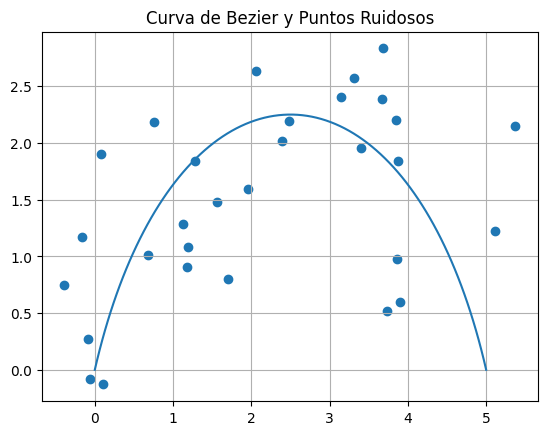

In [19]:
# Ejercicio 3

# Para la matriz C encontrada anteriormente.

# p0 = (0,0); p1 = (1,3); p2 = (4,3); p3 = (5,0)

# a) Tomar 30 valores m equiparados entre 0,1

def m30():
    contador = 0
    res = []
    i = 0
    while i <= 1:
        if contador == 30:
            return res
        contador = contador + 1
        res.append(i)
        i = i + 0.030 # va a tener aproximadamente 30 valores que van desde 0 hasta 1
    return res

valores30 = m30()
print(valores30)

# b) Evaluar los valores de la curva en estos 30 m.

def curva_en_m(m:list):
    # m pertenece a 0,1
    res = []
    p0 = [0,0]
    p1 = [1,3]               
    p2 = [4,3]
    p3 = [5,0]       

    for i in m:
        b1 = (1-i)**3
        b2 = 3*((1-i)**2)*i
        b3 = (3*(1-i))*i**2
        b4 = i**3

        valor1x = b1*p0[0]
        valor1y = b1*p0[1]
        valor2x = b2*p1[0] 
        valor2y = b2*p1[1]
        valor3x = b3*p2[0]
        valor3y = b3*p2[1]
        valor4x = b4*p3[0]
        valor4y = b4*p3[1] 

        res.append([valor1x+valor2x+valor3x+valor4x,valor1y+valor2y+valor3y+valor4y]) # Los dos x e y para cada valor de m
    
    return res

valores_t = curva_en_m(valores30)
print(valores_t)

# c)

np.random.seed(2)
# A cada coordenada añadir un poco de ruido. 
# Q = B(t) + z, con z vector el vector random

# generar ruido z en [-1,1] 
vector_entero = np.random.uniform(-1, 1, size=2)
print(vector_entero)

# Para cada valor dentro de B(t) con los 30 valores m.
# Q = B(t) + z

def puntos_ruido():
    res = []
    valores_t = curva_en_m(m30())
    for punto in valores_t:          # "punto" es cada [x, y] de la curva
        z = np.random.uniform(-1, 1, size=2)
        res.append([punto[0] + z[0], punto[1] + z[1]])
    return res

# d) Graficar los puntos con ruido, la curva original.

def puntos_x(C): # Calcula puntos x para dsp plotearlos
    res = []
    bezier = C
    for i in range(len(bezier)):
        res.append([bezier[i][0]])
    return res

puntosx = puntos_x(C)

def puntos_y(C): # Calcula puntos x para dsp plotearlos
    res = []
    bezier = C
    for i in range(len(bezier)):
        res.append([bezier[i][1]])
    return res

puntosy = puntos_y(C)


curva_ruido = puntos_ruido()
puntosxruido = puntos_x(curva_ruido)
puntosyruido = puntos_y(curva_ruido)


plt.plot(puntosx, puntosy)  #grafica la curva de bezier C
plt.scatter(puntosxruido, puntosyruido)  # grafica los puntos con ruido para cada Q = C + z que se hace en puntos_ruido()

plt.title("Curva de Bezier y Puntos Ruidosos")

plt.grid()
plt.show()



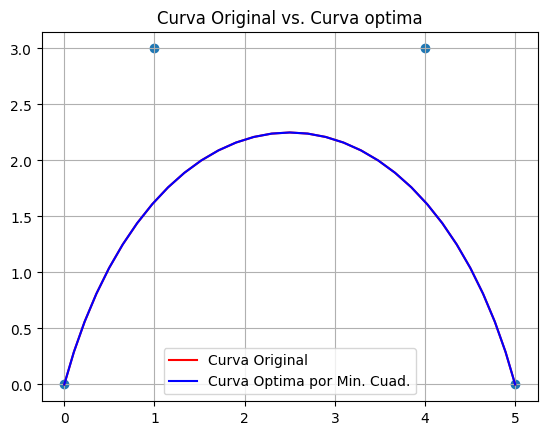

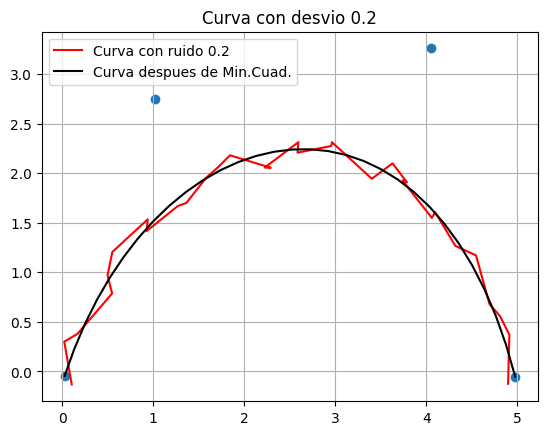

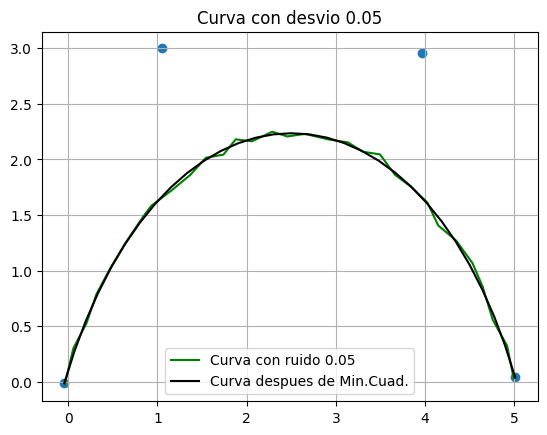

[[0.2, np.float64(0.0015076968308919815)], [0.05, np.float64(0.004021363245004087)]]


In [20]:
# Ejercicio 4 - Ajuste de Curva de Bezier por Minimos Cuadrados 

# a) Construir matriz A de mx4 con los polinomios de berstein evaluados.

def valores_m_entre_0_1(m:int):
    res = []
    i = 0
    valor_equidistante = 1 / m

    while i < 1:
        res.append(i)
        i = i + valor_equidistante # va a tener aproximadamente m valores entre 0 y 1 
    return res

def pol4_berstein_en_m(valores_m:list):
    # valores de m pertenece a 0,1
    res = []      

    for i in valores_m:
        b1 = (1-i)**3
        b2 = 3*((1-i)**2)*i
        b3 = (3*(1-i))*i**2
        b4 = i**3

        res.append([b1,b2,b3,b4]) 
    
    return res

# print(valores_m_entre_0_1(10)) # Da 10 valores entre 0 y 1 equidistantes.
# print(pol4_berstein_en_m(valores_m_entre_0_1(10))) # Evalua los polinomios de berstein para cada valor de m, en este caso 10.

# b) y c) Resolver el problema (A*P - Q)**2

A = np.array(pol4_berstein_en_m(valores_m_entre_0_1(30)))  # Matriz con valores de polinomios de berstein en 10 valores de t.

# Uso puntos de ejercicios anteriores.
p0 = np.array([0,0])
p1 = np.array([1,3])
p2 = np.array([4,3])
p3 = np.array([5,0])
P = np.array([p0, p1, p2, p3])

Q = A @ P 

# P --> Matriz con puntos
# A --> Matriz con valores de Berstein en valores de t
# Q --> Matriz con Valores de la curva de Bezier

# print(Q)

# P = (A^T * A)^(-1) * A^T * Q Para encontrar los puntos de control P que minimizan.
    

def ajuste_minimos_cuadrados( ):
    
    # Resuelve el problema de minimos cuadrados para encontrar los puntos de control P que mejor se ajusten a los puntos Q.

    A_transpuesta = np.transpose(A) # Transpuesta de A

    A_transpuesta_A = A_transpuesta @ A  # Producto de A^T y AÇ

    A_transpuesta_A_inversa = np.linalg.inv(A_transpuesta_A) # Inversa de A^T * A

    A_transpuesta_Q = A_transpuesta @ Q # A^T * Q 

    P_ajustado = A_transpuesta_A_inversa @ A_transpuesta_Q # P = (A^T * A)^(-1) * A^T * Q

    return P_ajustado       

def ajuste_minimos_cuadrados(A, Q):
    A_transpuesta = A.T
    A_transpuesta_A = A_transpuesta @ A
    A_transpuesta_A_inversa = np.linalg.inv(A_transpuesta_A)
    A_transpuesta_Q = A_transpuesta @ Q
    P_ajustado = A_transpuesta_A_inversa @ A_transpuesta_Q
    return P_ajustado

P_ajustado = ajuste_minimos_cuadrados(A, Q)
#print(P_ajustado)

# d) Graficar curva original, curva con puntos minimizada, puntos de control minimizados

Curva_original = A @ P
Curva_optima = A @ P_ajustado 
P_sombrero = ajuste_minimos_cuadrados(A, Q)

plt.plot(puntos_x(Curva_original), puntos_y(Curva_original),label="Curva Original", color = "red")
plt.plot(puntos_x(Curva_optima), puntos_y(Curva_optima),label="Curva Optima por Min. Cuad." ,color = "blue")

plt.title("Curva Original vs. Curva optima")
plt.legend()

Xs_sombrero = puntos_x(P_sombrero)
Ys_sombrero = puntos_y(P_sombrero)

plt.scatter(Xs_sombrero, Ys_sombrero)

plt.grid()
plt.show()
 
# En el grafico vemos que las curvas son las mismas y los puntos se aproximan casi iguales.
# Esto significa que el sistema ya tiene solución, por eso la solucion de minimos cuadrados dio 

# e) Los puntos practicamente los mismos que los pasados por enunciado. Tienen diferencias en decimales pero minimas seguramente porque con los calculos de los polinomios arrastran pequeños errores.        
# Podemos decir que son las mismas curvas porque como tiene solución unica, el problema de minimos cuadrados te de la misma curva que la original.

# f) Probar graficar las dos pero una curva Q con ruido.
# Usamos la matriz de puntos_ruido() para el ejercicio anterior. Con una matriz de 30x2


# Voy a usar dos desviación estandar de 0,2 y 0,05.

Curva_original = A @ P

Q_ruido_02 = Curva_original + np.array(np.random.uniform(-1,1, size=Curva_original.shape)*0.2) # curvas con ruido
Q_ruido_005 = Curva_original + np.array(np.random.uniform(-1,1, size=Curva_original.shape)*0.05)

P_02 = ajuste_minimos_cuadrados(A, Q_ruido_02)
P_05 = ajuste_minimos_cuadrados(A, Q_ruido_005)

#print(P_02)

plt.scatter(puntos_x(P_02),puntos_y(P_02))
plt.plot(puntos_x(Q_ruido_02),puntos_y(Q_ruido_02),label="Curva con ruido 0.2", color = "red")
plt.plot(puntos_x(A@P_02),puntos_y(A@P_02),label="Curva despues de Min.Cuad.", color = "black")
plt.title("Curva con desvio 0.2")

plt.legend()
plt.grid()
plt.show()

plt.scatter(puntos_x(P_05),puntos_y(P_05))
plt.plot(puntos_x(Q_ruido_005),puntos_y(Q_ruido_005), label="Curva con ruido 0.05", color = "green")
plt.plot(puntos_x(A@P_05),puntos_y(A@P_05),label="Curva despues de Min.Cuad.", color = "black")
plt.title("Curva con desvio 0.05")

plt.legend()
plt.grid()
plt.show()

# En los graficos vemos que a mas desvio estandar en los vectores de ruido (mas ruidosos) se deforma mas la cuerva de bezier.
# En la de 0.2 de sd se ve mas ruido en la curva.

# En la de 0.05 se ve mas fluida la curva

# Podemos decir que hacer el <proceso de minimos cuadrados con la curva estima el posible valor de la los puntos de control originales
# Pero con los vectores con ruido afectando a los valores de la curva.

# h) Calcular el error cuadratico medio de las dos curvas 1/m*(Curva_original - Curva_Desvio)^2

def ECM(C_0, C_1):
    res = 0
    m = len(C_0)
    for i in range(len(C_0)):
        calc0 = C_0[i][0] - C_1[i][0]
        calc1 = C_0[i][1] - C_1[i][1]

        res = res + (calc0+calc1)
    res = res**2
    res = 1/m*(res)
    return res

ECM_02 = ECM(Curva_original,A@P_02)
ECM_05 = ECM(Curva_original,A@P_05)

Tabla = [[0.2,ECM_02],[0.05,ECM_05]]
print(Tabla)

# i) A desvio estandar de los vectores de ruido mas altos se deforma mas la curva, es decir, es mayor el ECM.
# Si el desvio es muy chico la curva recupera aprox. su valor original.
# Con el nivel de desvio cambia tambien el desvio que tienen los puntos de control comparado a los demas.



In [21]:
# Ejercicio 5 - La funcion de error como forma cuadratica

# a) Expandir algebraicamente E(p) = ∥Ap −q∥^2 
# Verla como una forma cuadratica.
# Lo veo en el ipad.


![descripción](imagen-ejercicio-5-AUX.jpeg)

In [22]:
# d) Veamos los autovalores de la matriz simetria A^T*A

def autovalores_autovectores(A):
    A_transpuesta = np.transpose(A)
    autovalores, autovectores = np.linalg.eig(A_transpuesta @ A)
    return [ autovalores,autovectores ]

print(autovalores_autovectores(A))

# e) Los autovalores de A^T@A son todos positivos. Lo que significa que es una forma cuadratica positiva definida.
# Existe su minimo y es unico, esta dado por el minimo autovalor de A^T@A.

[array([7.76113293, 4.96556672, 1.75552262, 0.26536223]), array([[ 0.52106398,  0.67811834,  0.47800872, -0.20038841],
       [ 0.47800872,  0.20038841, -0.52106398,  0.67811834],
       [ 0.47800872, -0.20038841, -0.52106398, -0.67811834],
       [ 0.52106398, -0.67811834,  0.47800872,  0.20038841]])]


In [23]:
# Ejercicio 6 - Ecuaciones normales a partir del gradiente.
# El gradiente en este caso indica en que direccion y cuanto crece el error.

# Derivando el ECM y igualando a cero encontramos el minimo de la funcion gradiente. El minimo del problema. Lo mismo que hacemos en el problema de minimos cuadrados.
# Tenes que hacer el proceso muchas veces hasta intentar llevar al ECM a cero. Cuando es cero estas en el minimo del valle, el optimo local.
# https://www.youtube.com/watch?v=za61eVtq2MY


# a) Seguimos trabajando con p y q vectores.

def gradiente(p,A,q):
    A_transpuesta = np.transpose(A)
    calc = A@p - q
    calc1 = 2*A_transpuesta
    return calc1 @ calc

# b) Evaluar el gradiente en un vector inicial cualquiera, por ejemplo p = (0,0,0,0)T.

p = [0,0,0,0]
q = np.ones(len(A)) # Gernera un vector de 1`s con el tamaño de A para poder hacer la multiplicación.
res = gradiente(p, A, q)
# print(res) Para chequear que corre

# c) y d) Evaluar el gradiente en la solución de minimos cuadrados. El gradiente deberia acercarce mucho a cero.

# Pruebo con el p_hat que usamos con desvio estandar 0.05 que es la que mas se acercaba a la curva original.

print(gradiente(P_05,A,Q_ruido_005))
 
# El gradiente de la curva con desvio estandar de 0.05 es practicamente cero, esto significa que estamos practicamente en el optimo del problema. 




[[-2.47676621e-14 -9.98264631e-15]
 [-2.12966888e-14 -4.64556169e-15]
 [-1.85144753e-14  2.52405568e-15]
 [-3.46020567e-15  7.46439279e-15]]


![inciso e)](imagen-ejercicio-6-AUX.jpeg)

Si igualamos el gradiente a cero, obtenemos la ecuación normal. Esto significa que los puntos criticos de el gradiente son los puntos que encontramos por minimos cuadrados. El gradiente es una manera de encontrar el optimo del problema.

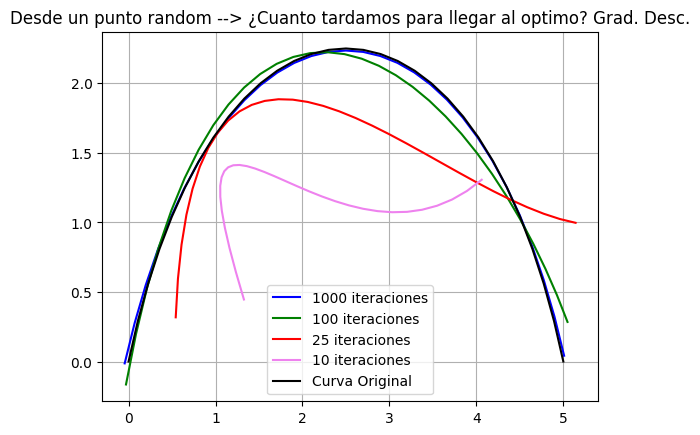

In [24]:
# Ejercicio 7 - Gradiente Descendiente para ajustar una curva

# Minimizar la ecuación: E(p) = (Ap-q)^2

# a) Iniciar p0 de manera aleatoria.

p = np.random.randn(4, 2)

# b) Implementar actualizacion p_t+1 = pt - α2A^T*(Apt-q)

# α = tasa de aprendizaje, un numero pequeño (0,01, 0,1) para ver cuanto avanzas en cada iteración del calculo del gradiente 
# (gradiente: derivada me dice donde esta el minimo). 
# Si α es muy grande → el algoritmo diverge (salta demasiado y no converge)
# Si α es muy pequeño → converge pero muy lento
# Si α es justo → converge al mínimo rápidamente

def actualizacion_gradiente(p,A,q,tasa_aprendizaje):
    anterior = gradiente(p,A,q)
    p_new = p - tasa_aprendizaje*anterior
    return p_new

# b) https://www.youtube.com/watch?v=za61eVtq2MY viendo este video sobre el descenso del gradiente dice que se fijan 1000 iteraciónes, vamos a probarlo.


def descenso_gradiente(iteraciones,A,p_inicial,q,tasa_aprendizaje):

    i = 0
    p = p_inicial.copy()
    res = [p.copy()]

    for i in range(iteraciones):
        p = p - tasa_aprendizaje * gradiente(p, A, q)
        res.append(p)

    return p, res

# c) y d) Graficar E(p) y graficar

P_1000, historial = descenso_gradiente(1000, A, p, Q_ruido_005, 0.01)

P_100, historial = descenso_gradiente(100, A, p, Q_ruido_005, 0.01)

P_25, historial = descenso_gradiente(25, A, p, Q_ruido_005, 0.01)

P_10, historial = descenso_gradiente(10, A, p, Q_ruido_005, 0.01)


# e) Graficar la curva original vs las encontradas por gradiente descendientes


plt.plot(puntos_x(A @ P_1000), puntos_y(A @ P_1000), label="1000 iteraciones", color = "blue")
plt.plot(puntos_x(A @ P_100), puntos_y(A @ P_100), label="100 iteraciones", color = "green")
plt.plot(puntos_x(A @ P_25), puntos_y(A @ P_25), label="25 iteraciones", color = "red")
plt.plot(puntos_x(A @ P_10), puntos_y(A @ P_10), label="10 iteraciones", color = "violet")

plt.plot(puntos_x(Curva_original), puntos_y(Curva_original), label="Curva Original", color = "black")

plt.title("Desde un punto random --> ¿Cuanto tardamos para llegar al optimo? Grad. Desc.")

plt.legend()
plt.grid()
plt.show()


# Podemos ver que a medida que pasan las iteraciones del metodo de gradiente descendiente se encuentra el optimo, bajando cada vez mas el 
# ECM.





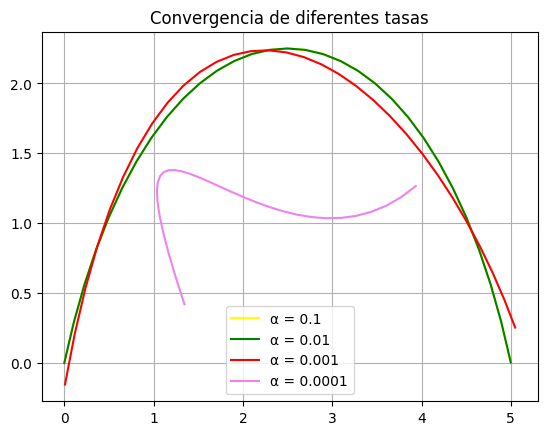

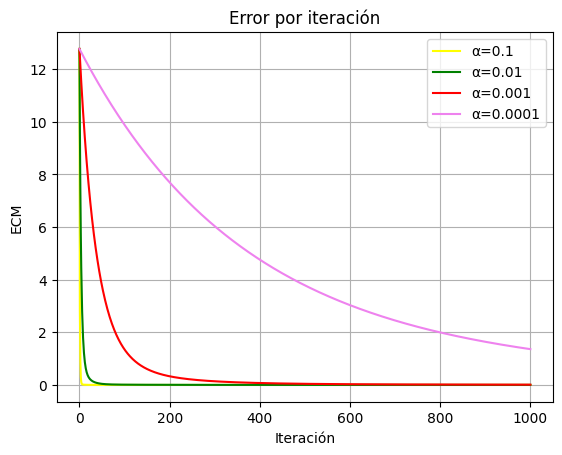

C:\Users\manue\AppData\Local\Temp\ipykernel_14944\3172086610.py:15: RuntimeWarning: overflow encountered in matmul
  return calc1 @ calc
C:\Users\manue\AppData\Local\Temp\ipykernel_14944\3172086610.py:13: RuntimeWarning: invalid value encountered in matmul
  calc = A@p - q


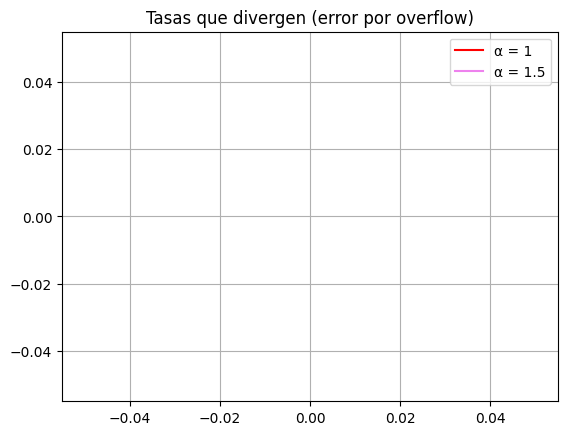

In [25]:
# Ejercicio 8 - Efecto de tasa de aprendizaje 

# a) Probar ejercicios de gradiente descendente con distintos valores de aprendizaje (α = 0,1; 0,01; 0,001; 0,0001)

# Pruebo devuelta como el ultimo ejercicio usar 1000 iteraciones por tasa de aprendizaje. 
# Tambien usamos la Q original para acercarnos con gradiente descendiente. 

P_tasa_01, historial1 = descenso_gradiente(1000, A, p, Q, 0.1)

P_tasa_001, historial2 = descenso_gradiente(1000, A, p, Q, 0.01)

P_tasa_0001, historial3 = descenso_gradiente(1000, A, p, Q, 0.001)

P_tasa_00001, historial4 = descenso_gradiente(1000, A, p, Q, 0.0001)

# b) Graficar curvas con distintos valores de tasa de aprendizaje

plt.plot(puntos_x(A @ P_tasa_01), puntos_y(A @ P_tasa_01), label="α = 0.1", color = "yellow")
plt.plot(puntos_x(A @ P_tasa_001), puntos_y(A @ P_tasa_001), label="α = 0.01", color = "green")
plt.plot(puntos_x(A @ P_tasa_0001), puntos_y(A @ P_tasa_0001), label="α = 0.001", color = "red")
plt.plot(puntos_x(A @ P_tasa_00001), puntos_y(A @ P_tasa_00001), label="α = 0.0001", color = "violet")
plt.title("Convergencia de diferentes tasas")

# plt.plot(puntos_x(Curva_original), puntos_y(Curva_original), label="Curva Original", color = "black")

plt.legend()
plt.grid()
plt.show()

# Graficar la funcion de error.

m = len(Q)

errores1 = [1/m * np.linalg.norm(A @ p_t - Q)**2 for p_t in historial1]
errores2 = [1/m * np.linalg.norm(A @ p_t - Q)**2 for p_t in historial2]
errores3 = [1/m * np.linalg.norm(A @ p_t - Q)**2 for p_t in historial3]
errores4 = [1/m * np.linalg.norm(A @ p_t - Q)**2 for p_t in historial4]

plt.plot(errores1, label="α=0.1",    color="yellow")
plt.plot(errores2, label="α=0.01",   color="green")
plt.plot(errores3, label="α=0.001",  color="red")
plt.plot(errores4, label="α=0.0001", color="violet")

plt.xlabel("Iteración")
plt.ylabel("ECM")
plt.title("Error por iteración")
plt.legend()
plt.grid()
plt.show()

# c) Para α = 0.0001 converge muy lentamente. Esto significa que cada iteracion se descubre a pasos chiquitos y esto hace que converga lentamente a la original.

# d) Para que no encuentre nunca la solución intuyo que la tasa de aprendizaje tiene que ser muy grande, cosa que, se pase del minimo optimo y de cualquier resultado.
# Pruebo con una tasa de 1 y 1.5 a ver que pasa.

P_tasa_1, historial = descenso_gradiente(1000, A, p, Q, 1)

P_tasa_1_5, historial = descenso_gradiente(1000, A, p, Q, 1.5)

plt.plot(puntos_x(A @ P_tasa_1), puntos_y(A @ P_tasa_1), label="α = 1", color = "red")
plt.plot(puntos_x(A @ P_tasa_1_5), puntos_y(A @ P_tasa_1_5), label="α = 1.5", color = "violet")
plt.title("Tasas que divergen (error por overflow)")
plt.legend()
plt.grid()
plt.show()

# Para estos dos graficos python me devuelve error por overflow. Es decir, el metodo en vez de converger en un minimo, se va y empieza a iterar infinitamente.
# Nunca encontrando el minimo.

# e) La tasa de aprendizaje funciona es una tasa a ajustar dependiendo el modelo que queramos ver.
# Su función es de cuanto queremos "pasos" queremos dar en cada iteración para ver que tan lejos estamos del minimo.
# Si vamos de a pasos muy agigantados el problema divergera como sucede con alpaha = 1 o 1.5
# Si vamos de a pasos muy cortos el problema convergera pero nos hacen falta muchas iteraciones como en alpha = 0.0001.

# Investigando con IA: El valor mas grande de alpha es: alpha_max = 1 / landa_max. Siendo landa el maximo autovalor de A^T*A.
# Lo cual tiene sentido por lo que vimos con matrices simetricas y formas cuadraticas. El landa mayor es el maximo punto de maximo de la Q(x).
# Una tasa de aprendizaje < 1 / landa_max --> Garantiza convergencia


[[ 6.66133815e-16  4.27435864e-15]
 [ 1.00000000e+00  3.00000000e+00]
 [ 4.00000000e+00  3.00000000e+00]
 [ 5.00000000e+00 -4.21884749e-15]]
[[-3.06421504e-16 -6.69254547e-16]
 [ 1.00000000e+00  3.00000000e+00]
 [ 4.00000000e+00  3.00000000e+00]
 [ 5.00000000e+00  6.20754248e-16]]


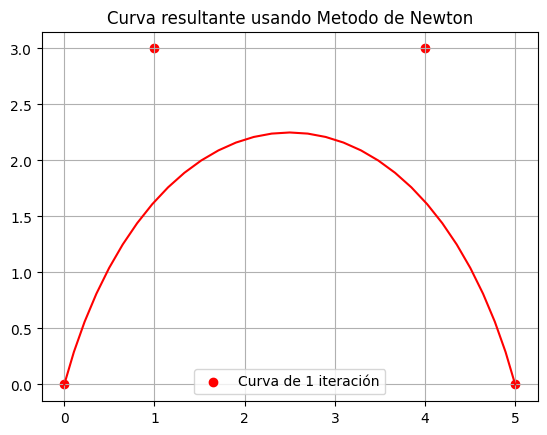

In [26]:
# Ejercicio 9 - Metodo Newton para el mismo problema de curvas de Bezier.

# E(p) = ∥Ap −q∥^2 --> La función cuadratica
# Hessiano = 2*(AT@A)

# a) Implementar el Metodo Newton 

def metodo_newton_iteracion(A,p,q):

    A_transpuesta = np.transpose(A)
    H = 2*(A_transpuesta@A)

    H_inversa = np.linalg.inv(H)

    grad = gradiente(p,A,q)

    p_new = p - H_inversa@grad

    return p_new

# b) Inicializo un vector 

p0 = np.random.randn(4, 2)

p1 = metodo_newton_iteracion(A,p0,Q)

print(p1)
print(P_tasa_01)

# Newton (1 iter):      Gradiente (1000 iter, α=0.1):
# [~0,  ~0 ]            [~0,  ~0 ]
# [1,    3  ]            [1,    3  ]
# [4,    3  ]            [4,    3  ]
# [5,   ~0  ]            [5,   ~0  ]

# c) Como resultado de los dos puntos podemos ver en el print que son practicamente iguales. Nos dan los puntos de la curva original ambos metodos.
# La conclusion que podemos sacar es que una iteración de Newton devuelve lo que mil iteraciones de gradiente descendiente devuelve.

# Con la ayuda de la IA llegue a ver las conclusiones de este problema.
# Newton llega directamente a la solución optima por medio de la Heussiana.
# Gradiente descendente tiene que hacer muchas iteraciones para poder llegar, haciendo pequeños saltos por iteración.

# d) Graficar las curvas x e y del resultado de la curva por Metodo de Newton.

plt.scatter(puntos_x(p1), puntos_y(p1), color = "red", label = "Curva de 1 iteración")
plt.plot(puntos_x(A@p1), puntos_y(A@p1),color="red")
plt.legend()
plt.title("Curva resultante usando Metodo de Newton")
plt.grid()
plt.show()

[[1. 3.]
 [4. 3.]]


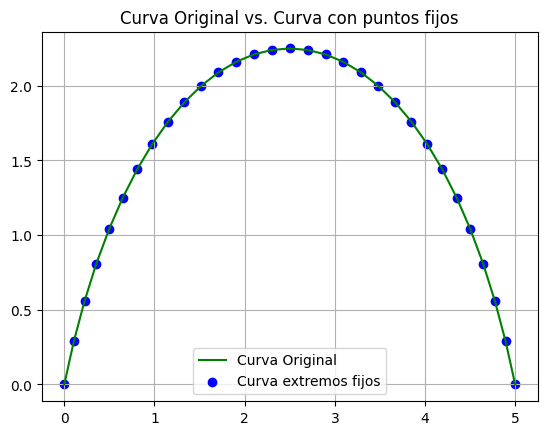

In [27]:
# Ejercicio 10 - Ajuste con extremos fijos

# a) Tomar p0 = q1, p3 = qm.
# Escribir la curva como = B(t) = b0(t)P0 + b1(t)P1 + b2(t)P2 + b3(t)P3

# Con p0 = q1, p3 = qm --> Q = b0(t)q1 + b1(t)P1 + b2(t)P2 + b3(t)qm

# b) Pasar los q`s conocidos del otro lado.
# Q - b0(t)q1 - b3(t)qm = b1(t)P1 + b2(t)P2 

# c) Q_new = A_int * [P1,P2] --> Con A_int teniendo solo los valores de b1(t) y b2(t)

# d) Resolver el problema para el nuevo Q_new y estimar solamente P1 y P2.

q1 = Q[0]
qm = Q[-1]

Q_nuevo = Q - np.outer(A[:,0], q1) - np.outer(A[:,3], qm) # Al Q anterior le resto los valores de b0`s * q1 y los b1`s * qm. 
# Quedan solamente los valores variables de P1 y P2.

# Para estimarlo uso el metodo newton encontrado en el anterior ejercicio.

p = np.random.randn(2, 2) # Incializo dos puntos random.

# A[filas, columnas] --> Uso slicing de numpy.

A_int = A[:,  1:3]  # Solo quedan las columnas de b1(t) y b2(t) --> Incluye columna 1 y no incluye la columna 3. --> Mantengo todas las filas.

# Usamos metodo de newton para en solamente 1 iteracion obtener el resultado optimo de minimos cuadrados.

P1y2 = metodo_newton_iteracion(A_int,p,Q_nuevo)
print(P1y2) 

# Como resultado tenemos los puntos: p1 = [1,3] y p2 = [4,3]. Solamente en una iteración.

# e) Graficar la curva original vs. la curva con puntos fijos.

puntos_curva_fija = [q1, P1y2[0], P1y2[1] , qm] # Extremos fijos con los puntos calculados por metodo de newton.
Q_new = A@puntos_curva_fija # Q con puntos fijos


plt.plot(puntos_x(Curva_original), puntos_y(Curva_original), label="Curva Original", color="green")
plt.scatter(puntos_x(Q_new), puntos_y(Q_new), label="Curva extremos fijos", color="blue") # Grafico con puntos asi se ve que son la misma curva.
plt.grid()
plt.legend()
plt.title("Curva Original vs. Curva con puntos fijos")
plt.show()

# Con ayuda de IA, este ejericicio me hizo entender su realización. Podemos reducir el problema para solamente tener que encontrar dos puntos y no cuatro.
# Me va a servir para el modelado del robot con A --> B fijos.




[[0.         0.        ]
 [0.40192044 0.88888889]
 [0.91906722 1.55555556]
 [1.51851852 2.        ]
 [2.16735254 2.22222222]
 [2.83264746 2.22222222]
 [3.48148148 2.        ]
 [4.08093278 1.55555556]
 [4.59807956 0.88888889]
 [5.         0.        ]]


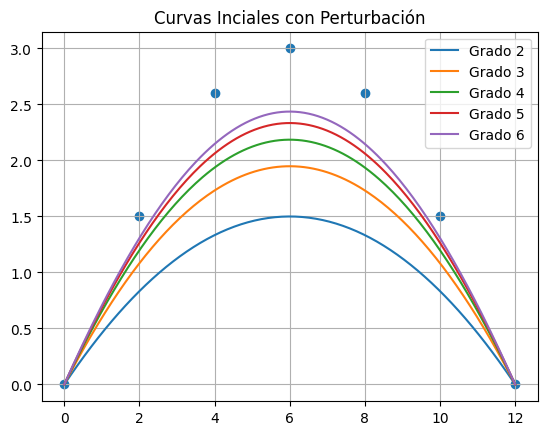

4
3
3
3
3


In [ ]:
# Ejercicio 11 - Aplicación: una trayectoria para la podadora robot

O = np.array([0, 0])
D = np.array([12, 0])

# O --> D estan fijos, los puntos n intermedios de la curva de bezier van a ser calculados.

# a) Implementar en Python una función bernstein(n, t) que devuelva la matriz de funciones base de Bernstein de grado n evaluadas en los valores de t recibidos. 

def berstein(n:int, t:list):

    # Devuelve las n funciones de berstein (columnas) evaluadas en t valores entre [0,1] (filas).
    # Devolver en una matriz de R^|t|*n

    matriz_resolucion = []
    for t_valor in t: # valores de t (filas --> valores de t)

        fila_t = []

        for k in range(n+1): # k es el valor del polinomio (columnas --> cantidad de polinomios de Berstein)
            
            # Con ayuda de la IA para ver como implementar esta funcion del polinomio de grado n.
            bn_t = comb(n, k) * (1 - t_valor)**(n - k) * t_valor**k
            
            fila_t.append(bn_t)
        
        matriz_resolucion.append(fila_t)

    return matriz_resolucion

def valores_t(cantidad: int): # devuelve |cantidad| igualmente espaciados valores de t entre 0 y 1.
    return np.linspace(0, 1, cantidad)

# b) Implementar una función bezier(P, t) que evalúe una curva de Bézier de grado arbitrario a partir de una matriz de puntos de control P ∈R(n+1)×2.

def bezier(P,t:list): # función que calcula nuestra Q = A@P (A la obtenemos de berstein(n,t))
    # P es la matriz que contiene los puntos de control de la curva de Bezier.

    n = len(P) - 1# Cantidad de columnas de P es la cantidad de curvas de bezier que tenemos que calcular
    A_n = berstein(n,t) # Tenemos nuestro A --> Matriz con valores para cada polinomio de berstein basado en valores de t.

    return A_n@P

# print(bezier(P,valores_t(10)))

# c) Implementar una función que, dados los puntos de una trayectoria muestreada, calcule la distan-
# cia mínima a cada obstáculo y determine si hay colisión. Diremos que hay colisión con el obstáculo
#    j si
#     min(i) ∥ Bn(ti) −cj ∥< rj .

# Represento los objetos en una matriz, cada objeto j tiene como primer valor el circ. y como segundo valor el radio. Su tamaño de j-1.

objetos = [
    [[2,1],   1  ],
    [[3,-2],  1  ],   
    [[5,0],   1.5],
    [[7,2],   1  ],
    [[8,-2],  1  ],
    [[6,-2],  0.5],
    [[10,1],  1.5],
    [[11,-2], 1  ],   
]

def colision(objetos, puntos_bezier):

    contador = 0

    for objeto in objetos:
        min = float('+inf') # Uso un numero muy positivo infinito para inicializar el primer minimo.
        centro = np.array(objeto[0])  # posicion del obstaculo.
        radio = objeto[1]
        
        for punto in puntos_bezier:
            if np.linalg.norm(np.array(punto) - centro) < min: # distancia euclidiana 
                min = np.linalg.norm(np.array(punto) - centro)
          
        if min < radio:
            contador = contador + 1
        
    return contador

# d) Usar N = 200 para los valores de t equidistantes.

# e) Usamos estos grados para las bezier n ∈ {2,3,4,5,6}. 
# O y D son extremos fijos.

# Pensamiento: calculo bezier de grado n, con slicing le saco los puntos O Y D.
# Chequeo si tiene colision con los objetos.
# Si no tiene colision --> le calculo la longitud.

def puntos_control_iniciales(n, a):
    puntos = []
    for k in range(n + 1):         # Por construcción matematica arrancara en (0,0) y terminara en (12,0)
        x = 12 * k / n
        y = a * np.sin(np.pi * k / n)
        puntos.append([x, y])
    return np.array(puntos)

# Pruebo usar a = 3 (mas para arriba se ve la curva), para cada grado hago una bezier distinta y grafico.

P_n2 = puntos_control_iniciales(2, 3)
Q_n2 = np.array(bezier(P_n2, valores_t(200)))

P_n3 = puntos_control_iniciales(3, 3)
Q_n3 = np.array(bezier(P_n3, valores_t(200)))

P_n4 = puntos_control_iniciales(4, 3)
Q_n4 = np.array(bezier(P_n4, valores_t(200)))

P_n5 = puntos_control_iniciales(5, 3)
Q_n5 = np.array(bezier(P_n5, valores_t(200)))

P_n6 = puntos_control_iniciales(6, 3)
Q_n6 = np.array(bezier(P_n6, valores_t(200)))

# f) Graficar

plt.plot(puntos_x(Q_n2), puntos_y(Q_n2), label="Grado 2")
plt.plot(puntos_x(Q_n3), puntos_y(Q_n3), label="Grado 3")
plt.plot(puntos_x(Q_n4), puntos_y(Q_n4), label="Grado 4")
plt.plot(puntos_x(Q_n5), puntos_y(Q_n5), label="Grado 5")
plt.plot(puntos_x(Q_n6), puntos_y(Q_n6), label="Grado 6")
plt.scatter(puntos_x(P_n6), puntos_y(P_n6))

plt.grid()
plt.legend()
plt.title("Curvas Inciales con Perturbación")
plt.show()

# Colisionan?

print(colision(objetos, Q_n2))
print(colision(objetos, Q_n3))
print(colision(objetos, Q_n4))
print(colision(objetos, Q_n5))
print(colision(objetos, Q_n6))

# Todas dieron true asi que colisionan todas las curvas. Todas colisionan con el primer objeto por donde salen su P1 (para arriba).

# g) Las curvas de grado bajo pueden tener problemas para atravesar el jardin ya que hay obstaculos muy cercanos a los puntos de control.
# Asi, chocandose con los primeros obstaculos.

# Las curvas de grado alto pueden generar muchos puntos de control como vemos en el grafico de la curva grado 6 sin mucho sentido.
# Porque, los obstaculos no estan demasiado arriba en el eje y, sino que, estan en el rango de (3,-3) en el eje y.

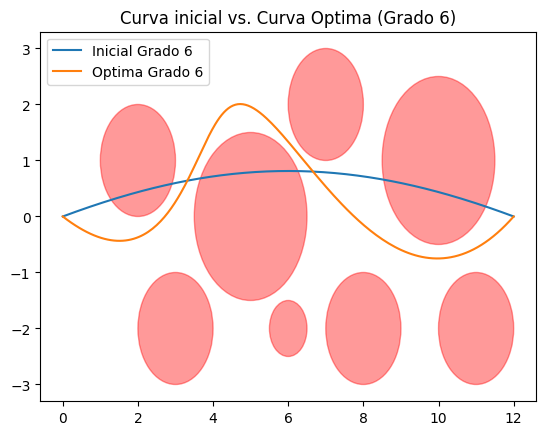

In [ ]:
# Ejercicio 12 - Optimización automática del grado y de la trayectoria 

# Queremos encontrar el camino suave, corto y que evite obstaculos. Para eso vamos a optimizar los puntos de control.

# θ es el vector de los puntos de control. Forma: [P1x P1y P2x P2y ··· Pn−1,x Pn−1,y]
# P0 y Pn permanecen fijos.

# Funcion de costo: E(θ) = Elargo(θ) + λsuavidad*Esuavidad(θ) + λobs*Eobstáculos(θ).

# a) Implementar en Python una función que convierta un vector θ en la matriz completa de puntos
#  de control P, agregando los extremos fijos P0 y Pn.

def convertirP(vector, p0, pn): # Pasa de θ a P para conseguir Q.
    res = [p0]
    temp = []
    for i in vector: # Ve todos los puntos seguidos.
        temp.append(i)
        if len(temp) == 2: # Agrupa los puntos de a dos.
            res.append(temp)
            temp = []
    res.append(pn)
    return res

# b) Implementar la funcion de Error dada por:
# E(θ) = Elargo(θ) + λsuavidad*Esuavidad(θ) + λobs*Eobstáculos(θ)

def error_largo(vector, inicio, fin):
    
    suma = 0
    
    # Contruccion de Q.
    P = convertirP(vector, inicio, fin)
    n = len(P) - 1 # Cantidad de columnas de P es la cantidad de puntos en la curva de bezier que tenemos que calcular.
    t = valores_t(200) # Dado por ejercicio anterior
    A_n = berstein(n, t)
    
    Q =  np.array(A_n)@np.array(P)

    for valores in range(len(Q)-1):
        
        resta = np.linalg.norm(Q[valores+1] - Q[valores]) # Resta euclidiana
        resta = resta**2
        suma = suma + resta
    
    return suma

# En error largo si tenemos mucha distancia entre puntos vecinos de la curva de Bezier penaliza mas.
# Mucha distancia entre puntos de la curva --> Mucha penalización

def error_suavidad(vector, inicio, fin):

    # Penaliza cambios bruscos entre puntos.

    P = convertirP(vector, inicio, fin)
    suma = 0

    for punto in range(1, len(P)-1): # Evito con -1 no ver el punto correcto.
        operacion = np.linalg.norm(np.array(P[punto-1] - 2*np.array(P[punto]) + P[punto+1])) # Distancia euclidiana
        operacion = operacion**2

        suma = suma + operacion

    return suma

# En el error de la suavidad penaliza mucho los "picos" entre los puntos. 
# Si el punto del medio se va mucho para arriba el 2* hace que se agrande mucho el error. 
# Premia los puntos mas rectos.

def error_obstaculo(vector, inicio, fin, obstaculos, delta):

    P = convertirP(vector, inicio, fin)
    n = len(P) - 1 # Cantidad de columnas de P es la cantidad de puntos en la curva de bezier que tenemos que calcular.
    t = valores_t(200) # Dado por ejercicio anterior
    A_n = berstein(n, t)
    
    Q =  np.array(A_n)@np.array(P)

    suma_general = 0

    for i in range(len(Q)):
        suma_parcial = 0
        
        for m in range(len(obstaculos)):
            
            resta_centro = np.linalg.norm(Q[i] - obstaculos[m][0]) # Resto mi posicion de Q - el centro del objeto
            radio_obstaculo = obstaculos[m][1]
            op = max(0, radio_obstaculo + delta - resta_centro)
            op = op**2

            suma_parcial = suma_parcial + op
        
        suma_general = suma_general + suma_parcial

    return suma_general

# El error de obstaculo penaliza mucho los puntos que estan cerca o adentro del obstaculo.
# El delta determina cuanto cerca se puede pasar del obstaculo

# Si estas muy cerca del centro (B - centro) es casi cero tenes una penalización muy alta.
# Si estas muy lejos del cero, se toma como cero y no tenes penalización.

def error(vector, inicio, fin, obstaculos, delta, landa_suav, landa_obs):

    E_l = error_largo(vector, inicio, fin)
    E_s = error_suavidad(vector, inicio, fin)
    E_o = error_obstaculo(vector, inicio, fin, obstaculos, delta)

    error_total = E_l + landa_suav*E_s + landa_obs*E_o

    return error_total

# Los landa`s sirven para ver cuanto vas a penalizar que la curva no sea suave o cuanto vas a penalizar que la recta este cerca de objetos.

# c) n ∈ {2, 3, 4, 5, 6}, λsuavidad = 0,1, λobs = 10, δ = 0,3. 
    
# Con la aproximación de diferencias finitas centrales encontrar para donde va la curva y implementar gradiente descendiente.

def iteracion_gradiente_robot(vector, inicio, fin, obstaculos, delta, landa_suav, landa_obs, epsilon):

    grad = np.zeros(len(vector)) # gradiente --> inicializa en ceros --> guarda cada derivada parcial
    
    for k in range(len(vector)): # veo para donde se mueve 
        ek = np.zeros(len(vector))
        ek[k] = 1                    # vector canónico: solo un 1 en posición k --> Muevo solamente una coordenada a la vez. 
                                     # El epsilon se suma solo en una coordenada a la vez.
        
        adelante = error(vector + epsilon * ek, inicio, fin, obstaculos, delta, landa_suav, landa_obs)
        atras    = error(vector - epsilon * ek, inicio, fin, obstaculos, delta, landa_suav, landa_obs)
        
        grad[k] = (adelante - atras) / (2 * epsilon) # ¿Para donde me muevo mas, para adelante o para atras?
    
    return grad

# Esta es la "derivada" del error. La iteramos muchas veces en el gradiente descendiente para ver a donde decrece el error.
# Vamos a tratar de movernos a donde el error se minimiza.
# En el vector, vemos donde el error decrece.

def gradiende_descendiente_robot(vector, inicio, fin, obstaculos, delta, landa_suav, landa_obs, epsilon, iteraciones, tasa):
    
    theta = vector.copy()
    
    for i in range(iteraciones):
        grad = iteracion_gradiente_robot(theta, inicio, fin, obstaculos, delta, landa_suav, landa_obs, epsilon)
        theta = theta - tasa * grad
    
    return theta

# d) Graficar el valor de E(theta) en cada iteración

# Estableci para todos los grados: a = 1 (determina curva inicial), tasa = 0.01 y iteraciones = 1000.

# Grado 2 
# puntos_sin_aplanar = puntos_control_iniciales(2, 1) # grado 2 y a = 1
# puntos_aplanados = puntos_sin_aplanar[1:-1].flatten()  # saca P0 y Pn, aplana a 1D
# res = gradiende_descendiente_robot(puntos_aplanados, O, D, objetos, 0.3, 0.1, 10, 0.001, 1000, 0.01)

# Grado 3
#puntos_sin_aplanar = puntos_control_iniciales(3, 1) # grado 3 y a = 1
#puntos_aplanados = puntos_sin_aplanar[1:-1].flatten()  # saca P0 y Pn, aplana a 1D
#res = gradiende_descendiente_robot(puntos_aplanados, O, D, objetos, 0.3, 0.1, 10, 0.001, 1000, 0.01)

# Grado 4
#puntos_sin_aplanar = puntos_control_iniciales(4, 1) # grado 4 y a = 1
#puntos_aplanados = puntos_sin_aplanar[1:-1].flatten()  # saca P0 y Pn, aplana a 1D
#res = gradiende_descendiente_robot(puntos_aplanados, O, D, objetos, 0.3, 0.1, 10, 0.001, 1000, 0.01)

# Grado 5
# puntos_sin_aplanar = puntos_control_iniciales(5, 1) # grado 5 y a = 1
# puntos_aplanados = puntos_sin_aplanar[1:-1].flatten()  # saca P0 y Pn, aplana a 1D
 # res = gradiende_descendiente_robot(puntos_aplanados, O, D, objetos, 0.3, 0.1, 10, 0.001, 1000, 0.01)

# Grado 6
#puntos_sin_aplanar = puntos_control_iniciales(6, 1) # grado 6 y a = 1
#puntos_aplanados = puntos_sin_aplanar[1:-1].flatten()  # saca P0 y Pn, aplana a 1D
#res = gradiende_descendiente_robot(puntos_aplanados, O, D, objetos, 0.3, 0.1, 10, 0.001, 1000, 0.01)

# Cada grafico de las 1000 iteraciónes por grado guardadas en la carpeta de figuras.

# e) Graficar trayectoria inicial y la trayectoria optima.

# Graficador de curva inicial y la optima encontrada por grad. desc.

# curva inicial
P_n2 = puntos_control_iniciales(6, 1)
Q_n2 = np.array(bezier(P_n2, valores_t(200)))
plt.plot(puntos_x(Q_n2), puntos_y(Q_n2), label="Inicial Grado 6")
for obj in objetos: # grafico objetos
        circulo = plt.Circle(obj[0], obj[1], color='red', alpha=0.4)
        plt.gca().add_patch(circulo)

# curva optimizada
puntos_aplanados = P_n2[1:-1].flatten()  # saca P0 y Pn, aplana a 1D para que la reciba bien la funcion como esta definido el problema
res = gradiende_descendiente_robot(puntos_aplanados, O, D, objetos, 0.3, 0.1, 10, 0.001, 1000, 0.01)

P = np.array(convertirP(res, O, D))
n = len(P) - 1
Q = np.array(berstein(n, valores_t(200))) @ P

plt.plot(puntos_x(Q), puntos_y(Q), label="Optima Grado 6")
plt.title("Curva inicial vs. Curva Optima (Grado 6)")
plt.legend()
plt.show()

# f) Criterio de trayectoria factible:
# --> No hay colisiones (lo chequeo en cada iteración con colision())
# --> Distancia minima a cualquier obstaculo sea al menos δ = 0.2 
# --> Criterio de suavidad alto (landa_suav = 0.1) para que un robot realmente no tenga que hacer picos raros que puedan arruinar su trayectoria.

# g) El menor grado n para poder construir una trayectoria factible es grado 3. 
# Con 1 solo punto distinto de los puntos de control (grado 2) no podemos encontrar una solución que cumpla el criterio de factibilidad.

C:\Users\manue\AppData\Local\Temp\ipykernel_14944\1667983470.py:168: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


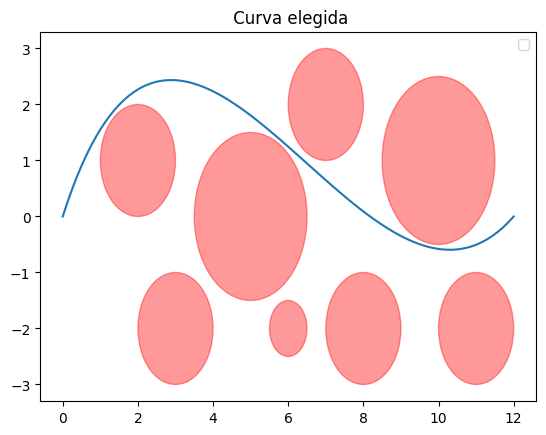

In [30]:
# Ejercicio 13 - Análisis de la trayectoria obtenida

# a) Construir una tabla comparando, para cada grado probado, la longitud aproximada de la trayec-
# toria, la cantidad de colisiones, la distancia mínima a un obstáculo y el valor final de la función
# de costo

def longitud_trayectoria(Q): # Funcion que calcula la longitud con distancia euclideana
    longitud = 0
    for i in range(len(Q) - 1):
        longitud += np.linalg.norm(Q[i+1] - Q[i])
    return longitud


# Formato de solucion de gradiente descendiente
Puntos_iniciales = puntos_control_iniciales(6, 1)
puntos_aplanados = Puntos_iniciales[1:-1].flatten()  # saca P0 y Pn, aplana a 1D para que la reciba bien la funcion como esta definido el problema
res = gradiende_descendiente_robot(puntos_aplanados, O, D, objetos, 0.3, 0.1, 10, 0.001, 1000, 0.01)

P = np.array(convertirP(res, O, D))
n = len(P) - 1
Q = np.array(berstein(n, valores_t(200))) @ P

def analizar_trayectoria(solucion, P, vector_plano, inicio, fin, obstaculos, delta, landa_suav, landa_obs):
    
    # Vector de vectores con: [[grado],[cant. colisiones],[longitud],[distancia min. obstaculo],[costo de solución]]

    res = []
    res.append([len(P)-1]) # grados de la solucion

    res.append([colision(objetos,np.array(solucion))]) # cant. de colisiones

    res.append([longitud_trayectoria(solucion)]) # longitud aproximada

    res.append([delta]) # la distancia minima a un objeto va a ser nuestro landa (δ = 0.2 --> tray.factible)

    res.append([error(vector_plano, inicio, fin, obstaculos, delta, landa_suav, landa_obs)])

    return res

# b) Comparar visualmente las trayectorias optimizadas para los distintos grados. ¿Qué cambia cuan-
# do aumenta el grado?

# A mas grados vemos mas curvatura en las trayectorias optimas obtenidas.
# Esto se da, ya que, en las curvas de bezier los puntos de control atraen a las curvas.

# c) Repetir el experimento para al menos tres valores distintos de λobs, por ejemplo:
#                               λobs ∈{1; 10; 100}.
        
# Por simplicidad voy a quedarme con la trayectoria que no tarda tanto en graficar que fue la de grado 4. 

# Prueba 1 - λobs = 1
#Puntos_iniciales = puntos_control_iniciales(4, 1)
#puntos_aplanados = Puntos_iniciales[1:-1].flatten()  # saca P0 y Pn, aplana a 1D para que la reciba bien la funcion como esta definido el problema
#res1 = gradiende_descendiente_robot(puntos_aplanados, O, D, objetos, 0.3, 0.1, 1, 0.001, 1000, 0.01)

#P1 = np.array(convertirP(res1, O, D))
#n = len(P1) - 1
#Q1 = np.array(berstein(n, valores_t(200))) @ P1

# Prueba 2 - λobs = 10
#Puntos_iniciales = puntos_control_iniciales(4, 1)
#puntos_aplanados = Puntos_iniciales[1:-1].flatten()  # saca P0 y Pn, aplana a 1D para que la reciba bien la funcion como esta definido el problema
#res2 = gradiende_descendiente_robot(puntos_aplanados, O, D, objetos, 0.3, 0.1, 10, 0.001, 1000, 0.01)

#P2 = np.array(convertirP(res2, O, D))
#n = len(P2) - 1
#Q2 = np.array(berstein(n, valores_t(200))) @ P2

# Prueba 3 - λobs = 100
#Puntos_iniciales = puntos_control_iniciales(4, 1)
#puntos_aplanados = Puntos_iniciales[1:-1].flatten()  # saca P0 y Pn, aplana a 1D para que la reciba bien la funcion como esta definido el problema
#res3 = gradiende_descendiente_robot(puntos_aplanados, O, D, objetos, 0.3, 0.1, 100, 0.001, 1000, 0.01)

#P3 = np.array(convertirP(res3, O, D))
#n = len(P3) - 1
#Q3 = np.array(berstein(n, valores_t(200))) @ P3

# Graficador:

#for obj in objetos: # grafico objetos
#        circulo = plt.Circle(obj[0], obj[1], color='red', alpha=0.4)
#        plt.gca().add_patch(circulo)
#plt.plot(puntos_x(Q1), puntos_y(Q1), label="λobs = 1")
#plt.plot(puntos_x(Q2), puntos_y(Q2), label="λobs = 10")
#plt.plot(puntos_x(Q3), puntos_y(Q3), label="λobs = 100")
#plt.title(" λobs = 1, 10 y 100 ")
#plt.legend()
#plt.show()

# En el grafico vemos como cada valor distinto de landa obstaculo establece que tan flexible con pasar cerca de los obstaculos.

# d) Repetir el experimento para al menos tres valores distintos de λsuavidad, por ejemplo:
#                           λsuavidad ∈{0; 0,1; 1}

# El landa de suavidad determina en el error mayor cuanto flexiblidad tiene con que la trayectoria sea suave.
# Es importante para el problema del robot ya que una trayectoria irregular imposibilitaria que el robot llegue sanamente al destino de O --> D.

# Experimento devuelta con curvas de grado 4, uso como parametro fijo de landa suavidad 10 que funciono bien en la ultima prueba.

# Prueba 1 - λsuav = 0
#Puntos_iniciales = puntos_control_iniciales(4, 1)
#puntos_aplanados = Puntos_iniciales[1:-1].flatten()  # saca P0 y Pn, aplana a 1D para que la reciba bien la funcion como esta definido el problema
#res1 = gradiende_descendiente_robot(puntos_aplanados, O, D, objetos, 0.3, 0, 10, 0.001, 1000, 0.01)

#P1 = np.array(convertirP(res1, O, D))
#n = len(P1) - 1
#Q1 = np.array(berstein(n, valores_t(200))) @ P1

# Prueba 2 - λsuav = 0.1
#Puntos_iniciales = puntos_control_iniciales(4, 1)
#puntos_aplanados = Puntos_iniciales[1:-1].flatten()  # saca P0 y Pn, aplana a 1D para que la reciba bien la funcion como esta definido el problema
#res2 = gradiende_descendiente_robot(puntos_aplanados, O, D, objetos, 0.3, 0.1, 10, 0.001, 1000, 0.01)

#P2 = np.array(convertirP(res2, O, D))
#n = len(P2) - 1
#Q2 = np.array(berstein(n, valores_t(200))) @ P2

# Prueba 3 - λsuav = 1
#Puntos_iniciales = puntos_control_iniciales(4, 1)
#puntos_aplanados = Puntos_iniciales[1:-1].flatten()  # saca P0 y Pn, aplana a 1D para que la reciba bien la funcion como esta definido el problema
#res3 = gradiende_descendiente_robot(puntos_aplanados, O, D, objetos, 0.3, 1, 10, 0.001, 1000, 0.01)

#P3 = np.array(convertirP(res3, O, D))
#n = len(P3) - 1
#Q3 = np.array(berstein(n, valores_t(200))) @ P3

# Graficador:

#for obj in objetos: # grafico objetos
#        circulo = plt.Circle(obj[0], obj[1], color='red', alpha=0.4)
#        plt.gca().add_patch(circulo)
#plt.plot(puntos_x(Q1), puntos_y(Q1), label="λsuav = 0")
#plt.plot(puntos_x(Q2), puntos_y(Q2), label="λsuav = 0.1")
#plt.plot(puntos_x(Q3), puntos_y(Q3), label="λsuav = 1")
#plt.title(" λsuav = 1, 10 y 100 ")
#plt.legend()
#plt.show()

# e) Para elegir una curva final, voy a priorizar mi 
#  Criterio de trayectoria factible:
# --> No hay colisiones (lo chequeo en cada iteración con colision())
# --> Distancia minima a cualquier obstaculo sea al menos δ = 0.2 
# --> Criterio de suavidad alto (landa_suav = 0.1) para que un robot realmente no tenga que hacer picos raros que puedan arruinar su trayectoria.

# Tambien, que tenga la menor cantidad de puntos de control asi tambien tenemos en cuenta la simpleza.
# Tiene que ser una curva que no tenga demasiada cercania a los obstaculos por precaucion del robot.

# Mi curva elegida: 

# 3 grados, landa_suav = 0.1, landa_obs = 10, tasa = 0.01. 

Puntos_iniciales = puntos_control_iniciales(3, 1)
puntos_aplanados = Puntos_iniciales[1:-1].flatten()  # saca P0 y Pn, aplana a 1D para que la reciba bien la funcion como esta definido el problema
res_elegida = gradiende_descendiente_robot(puntos_aplanados, O, D, objetos, 0.2, 0.1, 10, 0.001, 1000, 0.01)

P_elegida = np.array(convertirP(res_elegida, O, D))
n = len(P_elegida) - 1
Q_elegida = np.array(berstein(n, valores_t(200))) @ P_elegida

# Graficador:

for obj in objetos: # grafico objetos
        circulo = plt.Circle(obj[0], obj[1], color='red', alpha=0.4)
        plt.gca().add_patch(circulo)
plt.plot(puntos_x(Q_elegida), puntos_y(Q_elegida))

plt.title(" Curva elegida")
plt.legend()
plt.show()

# f) En este trabajo recorrimos muchos temas que vimos en la materia pero especificamente en la segunda parte de la materia.
# Primero, la idea de minimos cuadrados se ve claramente en la resolucion del problema usando metodo gradiente descendiente y metodo newton.
# El error viene dado por la formula ∥Ap −q∥^2, si igualamos la derivada a cero obtenemos las ecuaciones normales. En cada iteracion del gradiente descendiente
# usamos las ecuaciones normales para acercarnos poco a poco al optimo. 
# En el metodo de newton resolvemos minimos cuadrados en una sola iteración. Calculando la formula ecuaciones normales. 

# Para conectar con formas cuadraticas podemos ver que desarrollando la funcion del error obtenemos una forma cuadtratica en x*A^t@A*x. 
# Cuando le calculamos los autovalores vemos que son todos positivos. Dando a entender que es positiva definida. 
# Si la matriz A es positiva definida signfica que tenemos un unico minimo global. 
# Entonces, cuando hacemos metodo del gradiente y metodo de newton podemos factiblemente llegar a la mejor solución.
# (...) autovalores.

# Optimización numerica: encontrar max o min de una función cuando no podes resolverlo a mano --> Metodo de newton y metodo de gradiente descendiente. 

# Regularización: En el ej 12. Regularizas el peso del error de la suavidad o del error obstaculo con landa_obs y landa_suav.